<a href="https://colab.research.google.com/github/JanneWald/CS3960/blob/main/HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Part 1: Load/Analyze Data

##What is your dataset? Please describe your dataset and where you got it

I am using 2 datasets.
The first is a Kaggle dataset from Dr. Petro Ivaniuk called
[Football - FIFA World Cup, 1930 - 2022](https://www.kaggle.com/datasets/piterfm/fifa-football-world-cup)
It has 3 datafiles:
1. A list of all matches in the FIFA world cup from 1930 - 2022 with stats about them
2. Fifa ranking for all teams starting 2022 Qatari World Cup
3. A list of all world cups and some stats about them

**It was missing elo for all the matches however**

So I used second dataset that had them which I had to **scrape** from [eloratings](http://eloratings.net).

They have data for every match played for all global teams. I made a script in embedium but it was slow and hard to work with since the data wasn't in a nice http table.

Instead, I used the network console and found their api endpoint to get their tsv files. Now all I have to do is download all their tsv's and systematically add all the elo ratings for every game to the previous matches.




##Load your dataset / Implement your dataloader

In [2]:
# TODO - load your dataset and set up your dataloader
# If applicable, please include your data with your final submission
# along with instructions for how to load it

# TODO - if not already done, please make a train/val/test split of your dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Loading dataset
ranking = pd.read_csv('/content/fifa_ranking_2022-10-06.csv')
matches = pd.read_csv('/content/matches_1930_2022.csv')
wc = pd.read_csv('/content/world_cup.csv')

print("Dataset Loaded!")
print(f"Total World Cup matches: {len(matches)}")
ranking.head()
wc.head()
matches.head()

Dataset Loaded!
Total World Cup matches: 964


,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,away_manager,away_captain,Attendance,Venue,Officials,Round,Date,Score,Referee,Notes,Host,Year,home_goal,away_goal,home_goal_long,away_goal_long,home_own_goal,away_own_goal,home_penalty_goal,away_penalty_goal,home_penalty_miss_long,away_penalty_miss_long,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,Didier Deschamps,Hugo Lloris,88966,"Lusail Iconic Stadium, Lusail",Szymon Marciniak (Referee) · Paweł Sokolnicki ...,Final,2022-12-18,(4) 3–3 (2),Szymon Marciniak,Argentina won on penalty kicks following extra...,Qatar,2022,Ángel Di María · 36|Lionel Messi · 108,Kylian Mbappé · 81,['36&rsquor;|2:0|Ángel Di María|Assist:|Alexis...,['81&rsquor;|2:2|Kylian Mbappé|Assist:|Marcus ...,NaN,NaN,Lionel Messi (P) · 23,Kylian Mbappé (P) · 80|Kylian Mbappé (P) · 118,NaN,NaN,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua...",NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,Hoalid Regragui,Hakim Ziyech,44137,"Khalifa International Stadium, Doha",Abdulrahman Ibrahim Al Jassim (Referee) · Tale...,Third-place match,2022-12-17,2–1,Abdulrahman Ibrahim Al Jassim,NaN,Qatar,2022,Joško Gvardiol · 7|Mislav Oršić · 42,Achraf Dari · 9,['7&rsquor;|1:0|Joško Gvardiol|Assist:|Ivan Pe...,['9&rsquor;|1:1|Achraf Dari'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,Hoalid Regragui,Romain Saïss,68294,"Al Bayt Stadium, Al Khor",César Arturo Ramos (Referee) · Alberto Morín (...,Semi-finals,2022-12-14,2–0,César Arturo Ramos,NaN,Qatar,2022,Theo Hernández · 5|Randal Kolo Muani · 79,NaN,"['5&rsquor;|1:0|Theo Hernández', '79&rsquor;|2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,Zlatko Dalić,Luka Modrić,88966,"Lusail Iconic Stadium, Lusail",Daniele Orsato (Referee) · Ciro Carbone (AR1) ...,Semi-finals,2022-12-13,3–0,Daniele Orsato,NaN,Qatar,2022,Julián Álvarez · 39|Julián Álvarez · 69,NaN,"['39&rsquor;|2:0|Julián Álvarez', '69&rsquor;|...",NaN,NaN,NaN,Lionel Messi (P) · 34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,Fernando Santos,Pepe,44198,"Al Thumama Stadium, ath-Thumāma",Facundo Tello (Referee) · Ezequiel Brailovsky ...,Quarter-finals,2022-12-10,1–0,Facundo Tello,NaN,Qatar,2022,Youssef En-Nesyri · 42,NaN,['42&rsquor;|1:0|Youssef En-Nesyri|Assist:|Yah...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [3]:
# Master correction dictionary (expandable)
name_corrections = {
    'china pr': 'China',
    'czech republic': 'Czechia',
    'czechoslovakia': 'Czechia',
    'fr yugoslavia': 'Serbia',
    'germany dr': 'Germany',
    'ir iran': 'Iran',
    'korea dpr': 'North Korea',
    'korea republic': 'South Korea',
    'republic of ireland': 'Ireland',
    'soviet union': 'Russia',
    'türkiye': 'Turkey',
    'west germany': 'Germany',
    'zaire': 'Democratic Republic of Congo',
    'dr congo':'Democratic Republic of Congo'
}


# Remove these permanently
remove_teams = [
    "dutch east indies",
    "serbia and montenegro",
    "yugoslavia",
    "côte d'ivoire",
    "east germany",
    "saarland"
]

def clean_team_name(name):
    name = name.strip()

    lower_name = name.lower()
    if lower_name in remove_teams:
        return None

    if lower_name in name_corrections:
        return name_corrections[lower_name]

    # Standardize capitalization for eloratings uri
    lowercase_words = {'and', 'of', 'the'}
    parts = name.title().split()

    cleaned = []
    for i, w in enumerate(parts):
        wl = w.lower()
        if i > 0 and wl in lowercase_words:
            cleaned.append(wl)
        else:
            cleaned.append(w.capitalize())

    return " ".join(cleaned)

    return name

def clean_match_team_columns(df):
    df['home_team'] = df['home_team'].apply(clean_team_name)
    df['away_team'] = df['away_team'].apply(clean_team_name)

    df = df.dropna(subset=['home_team', 'away_team'])
    return df

# Apply cleaning
matches_clean = clean_match_team_columns(matches.copy())

print("Before:", len(matches))
print("After:", len(matches_clean))

matches = matches_clean
matches_clean.head()

Before: 964
After: 919


,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,away_manager,away_captain,Attendance,Venue,Officials,Round,Date,Score,Referee,Notes,Host,Year,home_goal,away_goal,home_goal_long,away_goal_long,home_own_goal,away_own_goal,home_penalty_goal,away_penalty_goal,home_penalty_miss_long,away_penalty_miss_long,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,Didier Deschamps,Hugo Lloris,88966,"Lusail Iconic Stadium, Lusail",Szymon Marciniak (Referee) · Paweł Sokolnicki ...,Final,2022-12-18,(4) 3–3 (2),Szymon Marciniak,Argentina won on penalty kicks following extra...,Qatar,2022,Ángel Di María · 36|Lionel Messi · 108,Kylian Mbappé · 81,['36&rsquor;|2:0|Ángel Di María|Assist:|Alexis...,['81&rsquor;|2:2|Kylian Mbappé|Assist:|Marcus ...,NaN,NaN,Lionel Messi (P) · 23,Kylian Mbappé (P) · 80|Kylian Mbappé (P) · 118,NaN,NaN,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua...",NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,Hoalid Regragui,Hakim Ziyech,44137,"Khalifa International Stadium, Doha",Abdulrahman Ibrahim Al Jassim (Referee) · Tale...,Third-place match,2022-12-17,2–1,Abdulrahman Ibrahim Al Jassim,NaN,Qatar,2022,Joško Gvardiol · 7|Mislav Oršić · 42,Achraf Dari · 9,['7&rsquor;|1:0|Joško Gvardiol|Assist:|Ivan Pe...,['9&rsquor;|1:1|Achraf Dari'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,Hoalid Regragui,Romain Saïss,68294,"Al Bayt Stadium, Al Khor",César Arturo Ramos (Referee) · Alberto Morín (...,Semi-finals,2022-12-14,2–0,César Arturo Ramos,NaN,Qatar,2022,Theo Hernández · 5|Randal Kolo Muani · 79,NaN,"['5&rsquor;|1:0|Theo Hernández', '79&rsquor;|2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,Zlatko Dalić,Luka Modrić,88966,"Lusail Iconic Stadium, Lusail",Daniele Orsato (Referee) · Ciro Carbone (AR1) ...,Semi-finals,2022-12-13,3–0,Daniele Orsato,NaN,Qatar,2022,Julián Álvarez · 39|Julián Álvarez · 69,NaN,"['39&rsquor;|2:0|Julián Álvarez', '69&rsquor;|...",NaN,NaN,NaN,Lionel Messi (P) · 34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,Fernando Santos,Pepe,44198,"Al Thumama Stadium, ath-Thumāma",Facundo Tello (Referee) · Ezequiel Brailovsky ...,Quarter-finals,2022-12-10,1–0,Facundo Tello,NaN,Qatar,2022,Youssef En-Nesyri · 42,NaN,['42&rsquor;|1:0|Youssef En-Nesyri|Assist:|Yah...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [4]:
def get_result(row):
  home_goals = row['home_score']
  away_goals = row['away_score']

  if home_goals > away_goals:
    return 2 # Home Win
  if home_goals == away_goals:
    return 1 # Draw
  else:
    return 0 # Home Loss

matches['result'] = matches.apply(get_result, axis=1)

matches[['home_team', 'away_team', 'home_score', 'away_score', 'result']].head(10)

,home_team,away_team,home_score,away_score,result
0,Argentina,France,3,3,1
1,Croatia,Morocco,2,1,2
2,France,Morocco,2,0,2
3,Argentina,Croatia,3,0,2
4,Morocco,Portugal,1,0,2
5,England,France,1,2,0
6,Croatia,Brazil,1,1,1
7,Netherlands,Argentina,2,2,1
8,Morocco,Spain,0,0,1
9,Portugal,Switzerland,6,1,2


In [5]:
train = matches[matches['Year'] < 2010]
val = matches[matches['Year'] == 2014]
test = matches[matches['Year'] == 2018]

print("Train:", len(train))
print("Val:", len(val))
print("Test:", len(test))

Train: 669
Val: 61
Test: 64


In [6]:
# Scrape EloRatings.net per-team match history, cache results, and merge Elo into your matches df
import requests
import os
from collections import Counter

def find_team_abbr(tsv_lines):
    """Gets the team abbreviation for the country used in eloratings dataset in their tsv"""
    abbr_counter = Counter()

    for line in tsv_lines:
        cols = line.split('\t')
        if len(cols) < 5:
            continue  # Skip malformed rows

        abbr_1 = cols[3]
        abbr_2 = cols[4]
        abbr_counter[abbr_1] += 1
        abbr_counter[abbr_2] += 1

    # Get the most common abbreviation and its count, should be any over half
    most_common_abbr, count = abbr_counter.most_common(1)[0]

    return most_common_abbr


from collections import defaultdict
team_abr = defaultdict(str)

# Get unique teams from home and away columns
home_teams = matches['home_team'].unique()
away_teams = matches['away_team'].unique()

# Get unique team names
all_teams = set(home_teams) | set(away_teams)
all_teams = sorted(all_teams)

print(f"Total unique teams: {len(all_teams)}")
print(all_teams)

failed_teams = []

elo_dir = '/content/elos'
os.makedirs(elo_dir, exist_ok=True)

# Scrape tsv for each team and save abbreviation
for team in all_teams:
    team = team.replace(' ', '_')
    url = f'http://www.eloratings.net/{team}.tsv'
    print(f"Downloading {url}")

    resp = requests.get(url)

    if resp.status_code == 200:
        # Get Abbreviation for team
        tsv_content = resp.text
        tsv_lines = tsv_content.strip().split('\n')
        abbr = find_team_abbr(tsv_lines)
        team_abr[team] = abbr

        # Save file
        with open(f"{elo_dir}/{team}.tsv", 'wb') as f:
            f.write(resp.content)
            print('Saved', abbr)
    else:
        print(f"Failed to download {url}")
        failed_teams.append(team)

print('Failed teams:')
print(failed_teams)

Total unique teams: 77
['Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cameroon', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Czechia', 'Democratic Republic of Congo', 'Denmark', 'Ecuador', 'Egypt', 'El Salvador', 'England', 'France', 'Germany', 'Ghana', 'Greece', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Kuwait', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'North Korea', 'Northern Ireland', 'Norway', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russia', 'Saudi Arabia', 'Scotland', 'Senegal', 'Serbia', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Togo', 'Trinidad and Tobago', 'Tunisia', 'Turkey', 'Ukraine', 'United Arab Emirates', 'United States', 'Uruguay', 'Wales']
Saved DZ
Saved AO
Saved AR
Saved AU
Saved AT
Saved BE

In [7]:
import pandas as pd
from datetime import datetime

def load_team_elo_df(team, abbr, folder='/content/elos'):
    """Load the team's TSV into a DataFrame with parsed date column"""
    path = f"{folder}/{team}.tsv"
    df = pd.read_csv(path, sep='\t', header=None)
    df.head()

    # Build datetime column
    df['date_str'] = df[0].astype(str) + '-' + df[1].astype(str).str.zfill(2) + '-' + df[2].astype(str).str.zfill(2)
    df['date'] = pd.to_datetime(df['date_str'], errors='coerce')

    df['abbr_home'] = df[3]
    df['abbr_away'] = df[4]
    df['elo_home'] = df[10]
    df['elo_away'] = df[11]
    df['abbr'] = abbr  # store the team's abbreviation
    return df

def find_closest_elo(df, match_date, team_abbr, is_home):
    """Given a date and a team, finds the closest match it can find in the history and records its elo at that time"""
    # Filter rows where team abbreviation matches on home or away column accordingly
    if is_home:
        relevant_rows = df[df['abbr_home'] == team_abbr]
        elo_col = 'elo_home'
    else:
        relevant_rows = df[df['abbr_away'] == team_abbr]
        elo_col = 'elo_away'

    past_rows = relevant_rows[relevant_rows['date'] <= match_date]

    if past_rows.empty:
        return float('nan')

    # Pick the row with the max date <= match_date
    closest_row = past_rows.loc[past_rows['date'].idxmax()]

    return closest_row[elo_col]

def add_elo_ratings_to_matches(matches, team_abr, elo_folder='/content/elos'):
    """Systematically goes through all matches and adds the elo ratings per team per game from gathered elo files"""
    # Caching dataframes to save on loader compute
    team_elo_dfs = {}

    home_elo_list = []
    away_elo_list = []

    for idx, row in matches.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        #print(home_team)

        # converting date colmns to datetime
        if 'Date' in matches.columns:
            match_date = pd.to_datetime(row['Date'])
        else:
            # fallback to use year only
            match_date = pd.to_datetime(f"{row['Year']}-01-01")
        #print(match_date)

        # Get abbreviations
        home_abbr = team_abr.get(home_team, None)
        away_abbr = team_abr.get(away_team, None)
        print(home_abbr, away_abbr)

        if home_abbr is None or away_abbr is None:
            home_elo_list.append(float('nan'))
            away_elo_list.append(float('nan'))
            continue

        #print('Hello')

        # Load TSVs for teams if not cached
        home_team = home_team.replace(' ', '_')
        away_team = away_team.replace(' ', '_')
        if home_team not in team_elo_dfs:
            team_elo_dfs[home_team] = load_team_elo_df(home_team, home_abbr, elo_folder)
        if away_team not in team_elo_dfs:
            team_elo_dfs[away_team] = load_team_elo_df(away_team, away_abbr, elo_folder)

        #print('Hello')

        home_elo = find_closest_elo(team_elo_dfs[home_team], match_date, home_abbr, is_home=True)
        away_elo = find_closest_elo(team_elo_dfs[away_team], match_date, away_abbr, is_home=False)

        home_elo_list.append(home_elo)
        away_elo_list.append(away_elo)

    matches['home_elo'] = home_elo_list
    matches['away_elo'] = away_elo_list

    return matches


In [8]:
matches_with_elo = add_elo_ratings_to_matches(matches, team_abr, elo_folder='/content/elos')
matches_with_elo.to_csv('/content/matches_with_elo.csv', index=False)


AR FR
HR MA
FR MA
AR HR
MA PT
EN FR
HR BR
NL AR
MA ES
PT CH
JP HR
BR None
FR PL
EN SN
NL None
AR AU
None PT
GH UY
CM BR
YU CH
CA MA


/tmp/ipython-input-2966747758.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date_str'], errors='coerce')
/tmp/ipython-input-2966747758.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date_str'], errors='coerce')


HR BE
None DE
JP ES
AU DK
TN FR
None MX
PL AR
EC SN
NL QA
IR None
WA EN
CM YU
None GH
BR CH
PT UY
JP None
BE MA
HR CA
ES DE
TN AU
PL None
FR DK
AR MX
WA IR
QA SN
NL EC
EN None
CH CM
UY None
PT GH
BR YU
MA HR
DE JP
ES None
BE CA
AR None
DK TN
MX PL
FR AU
EN IR
SN NL
None WA
QA EC
FR HR
BE EN
HR EN
FR BE
SE EN
SU HR
UY FR
BR BE
SE CH
CO EN
BR MX
BE JP
ES SU
HR DK
FR AR
UY PT
JP PL
SN CO
EN BE
PA TN
None DE
MX SE
CH None
YU BR
AU PE
DK FR
IS HR
NG AR
None EG
UY SU
ES MA
IR PT
EN PA
JP SN
PL CO
BE TN
None MX
DE SE
BR None
NG IS
YU CH
DK AU
FR PE
AR HR
PT MA
UY None
IR ES
CO JP
PL SN
SU EG
SE None
BE PA
TN EN
None YU
DE MX
BR CH
FR AU
AR IS
PE DK
HR NG
EG UY
MA IR
PT ES
SU None
DE AR
BR NL
NL AR


/tmp/ipython-input-2966747758.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date_str'], errors='coerce')


BR DE
AR BE
NL None
FR DE
BR CO
AR CH
BE None
FR NG
DE DZ
NL MX
None GR
BR CL
CO UY
None DE
PT GH
None BE
DZ SU
None IR
NG AR
HN CH
EC FR
None EN
IT UY
JP CO
AU ES
NL CL
HR MX
CM BR
BE SU
None DZ
None PT
AR IR
DE GH
NG None
IT None
CH FR
HN EC
UY EN
JP GR
AU NL
ES CL
CM HR
BE DZ
BR MX
SU None
DE PT
IR NG
GH None
CH EC
FR HN
AR None
CO GR
UY None
EN IT
MX CM
ES NL
CL AU
BR HR
NL ES
UY DE
DE ES
UY NL
AR DE
PY ES
NL BR
UY GH
PY JP
ES PT
NL SK
BR CL
DE EN
AR MX
UY None
None GH
PT BR
CL ES
CH HN
PY None
SK IT
DK JP
CM NL
SI EN
None DZ
GH DE
AU YU
MX UY
FR None
NG None
GR AR
PT None
CL CH
ES HN
SK PY
IT None
NL JP
GH AU
CM DK
DE YU
SI None
EN DZ
AR None
GR NG
FR MX
HN CL
ES CH
None UY
None SK
BR None
NL DK
JP CM
IT PY
DZ SI
YU GH
DE AU
None GR
AR NG
EN None
None MX
UY FR
IT FR
DE PT
PT FR
DE IT
EN PT
BR FR
DE AR
IT UA
BR GH
ES FR
IT AU
CH UA
EN EC
PT NL
DE SE
AR MX
None ES
UA TN
TG FR


/tmp/ipython-input-2966747758.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date_str'], errors='coerce')


CH None
GH None
CS IT
JP BR
HR AU
PT MX
IR AO
NL AR
None PL
EC DE
PY None
SE EN
TG CH
None UA
ES TN
JP HR
BR AU
FR None
PT IR
CS GH
IT None
MX AO
EC None
EN None
SE PY
ES UA
TN None
DE PL
None TG
FR CH
BR HR
AU JP
None CS
IT GH
MX IR
AO PT
EN PY
None SE
DE None
PL EC
DE BR
None TR
BR TR
DE None
ES None
SN TR
EN BR
DE None
JP TR
None IT
MX None
BR BE
SE SN
ES IE
DE PY
DK EN
TN JP
BE SU
PT None
PL None
None BR
TR CN
MX IT
EC HR
SE AR
NG EN
None ES
SI PY
DK FR
SN UY
None IE
CM DE
None None
TN BE
PT PL
MX EC
None TR
JP SU
None SI
IT HR
BR CN
SE NG
ES PY
AR EN
DK SN
CM None
FR UY
SU TN
None PT
DE IE
CN None
JP BE
None PL
HR MX
BR TR
IT EC
AR NG
PY None
EN SE
ES SI
IE CM
UY DK
DE None
FR SN
BR FR
NL HR
FR HR
BR NL
NL AR
DE HR
IT FR
BR DK
RO HR
AR EN
DE MX
NL YU
FR PY
NG DK
IT NO
BR CL
AR HR
JP JM
RO TN
CO EN
NL MX
BE None
None YU
DE IR
None None
FR DK
ES BG
NG PY
IT AT
CL CM
BR NO
SQ MA
CO TN
RO EN
DE YU
AR JM
None IR
JP HR
BE MX
NL None
NG BG
ES PY
None DK
FR None
CL AT
IT CM
SQ NO
BR MA
EN

##  Dataset Analyis Statistics

### Most Common Teams

In [9]:
df = matches_with_elo.copy()

# Get the 10 most common teams appearing as home/away
team_counts = (
    pd.concat([df['home_team'], df['away_team']])
    .value_counts()
)

top10_teams = team_counts.head(10).index.tolist()
print("Top 10 Teams:", top10_teams)

Top 10 Teams: ['Germany', 'Brazil', 'Argentina', 'Italy', 'England', 'France', 'Spain', 'Mexico', 'Uruguay', 'Netherlands']


### Elo Ratings of Matches over Time

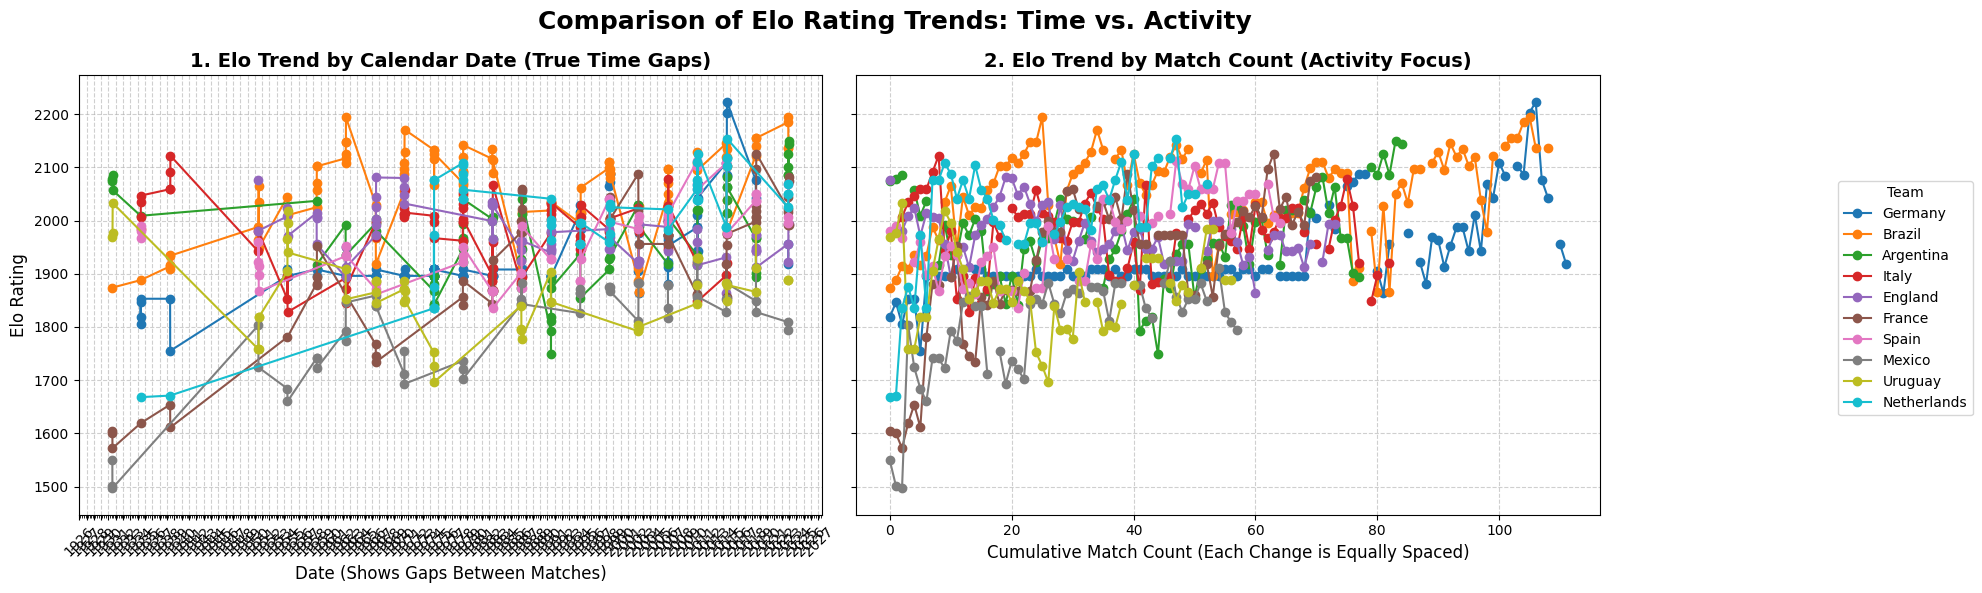

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # This is the import needed for mdates


#chart_df = matches_with_elo[
#    (matches_with_elo['home_team'].isin(top10_teams)) |
#    (matches_with_elo['away_team'].isin(top10_teams))
#].copy()

matches_with_elo['Date'] = pd.to_datetime(matches_with_elo['Date'], errors='coerce')
matches_with_elo = matches_with_elo.dropna(subset=['Date'])

# Filter to only top 10 teams
chart_df = matches_with_elo[
    (matches_with_elo['home_team'].isin(top10_teams)) |
    (matches_with_elo['away_team'].isin(top10_teams))
].copy()


def prepare_elo_time_series(df, relevant_teams):
    """
    Transforms our match elo data into a time series for plotting.
    """
    elo_records = []

    for _, row in df.iterrows():
        date = row['Date']

        # Record Home Team Elo if it's a team we care about
        if row['home_team'] in relevant_teams:
            elo_records.append({
                'Date': date,
                'Team': row['home_team'],
                'Elo': row['home_elo']
            })

        # Record Away Team Elo if it's a team we care about
        if row['away_team'] in relevant_teams:
            elo_records.append({
                'Date': date,
                'Team': row['away_team'],
                'Elo': row['away_elo']
            })

    # Make DF sorted chronologically
    elo_ts_df = pd.DataFrame(elo_records)
    elo_ts_df = elo_ts_df.sort_values(by='Date').reset_index(drop=True)

    return elo_ts_df

elo_time_series = prepare_elo_time_series(chart_df, top10_teams)


def plot_elo_comparison(df, teams_to_plot):
    """
    Plots the Elo rating over time for the specified teams in two diff subplots:
    1 with X-axis by Calendar Date (shows true gaps).
    Another with X-axis by Match Index (compresses time gaps for activity focus).
    """
    # side-by-side figures
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

    # Calculate global Elo range for consistent Y-axis
    if not df.empty:
        min_elo = df['Elo'].min() - 50
        max_elo = df['Elo'].max() + 50
        y_lim = (min_elo, max_elo)
    else:
        y_lim = (1400, 1800)

    for team in teams_to_plot:
        team_data = df[df['Team'] == team].sort_values(by='Date')

        match_index = range(len(team_data))

        # Calendar Date
        ax1.plot(
            team_data['Date'],
            team_data['Elo'],
            label=team,
            marker='o',
            linestyle='-'
        )

        # Match Index
        ax2.plot(
            match_index,
            team_data['Elo'],
            label=team,
            marker='o',
            linestyle='-'
        )

    # Calendar axis
    ax1.set_title('1. Elo Trend by Calendar Date (True Time Gaps)', fontsize=14, weight='bold')
    ax1.set_xlabel('Date (Shows Gaps Between Matches)', fontsize=12)
    ax1.set_ylabel('Elo Rating', fontsize=12)

    #  date formatting
    date_format = mdates.DateFormatter('%Y')
    ax1.xaxis.set_major_formatter(date_format)
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
    ax1.tick_params(axis='x', rotation=45)

    # Match Index axis
    ax2.set_title('2. Elo Trend by Match Count (Activity Focus)', fontsize=14, weight='bold')
    ax2.set_xlabel('Cumulative Match Count (Each Change is Equally Spaced)', fontsize=12)

    #  Flavor
    ax1.set_ylim(y_lim)
    ax2.set_ylim(y_lim)

    ax1.grid(axis='both', linestyle='--', alpha=0.6)
    ax2.grid(axis='both', linestyle='--', alpha=0.6)

    # Same legend
    fig.legend(
        labels=teams_to_plot,
        title='Team',
        bbox_to_anchor=(1.02, 0.5),
        loc='center left'
    )

    fig.suptitle('Comparison of Elo Rating Trends: Time vs. Activity', fontsize=18, weight='bold')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

# Execute order plotting
if not elo_time_series.empty:
    plot_elo_comparison(elo_time_series, top10_teams)
else:
    print("No data found for the specified top teams to plot.")


# Part 2: Literature Review

### Paper 1
Citation
```txt
Albert Wong, Eugene Li, Huan Le, Gurbir Bhangu, Suveer Bhatia,
A predictive analytics framework for forecasting soccer match outcomes using machine learning models,
Decision Analytics Journal,
Volume 14,
2025,
100537,
ISSN 2772-6622,
https://doi.org/10.1016/j.dajour.2024.100537.
(https://www.sciencedirect.com/science/article/pii/S2772662224001413)
```

This was one of the first papers I read. Their goal was to build a predictive model for forcasting soccer matches like myself but in the English Premier League (EPL)

They used historical match results, **but also** incorporated additional features: publicly available game results, weather data, and their own metric of team fatigue and momentum.

They thought these extra features would improve predictive performance beyond “just results-based” features.

They compared many models.
`logistic regression (LR), random forest (RF), support vector machine (SVM), and XGboost (XGB)`

As well as a LightGBM and CNN model.

According to the paper, their models “showed promise compared to those derived from odds given by major bookmakers.”
ScienceDirect

### Paper 2
Citation
```text
Jain, Sarika & Tiwari, Ekansh & Sardar, Prasanjit. (2021).
Soccer Result Prediction Using Deep Learning and Neural Networks.
10.1007/978-981-15-9509-7_57.
(https://www.researchgate.net/publication/349272309_Soccer_Result_Prediction_Using_Deep_Learning_and_Neural_Networks)
```
Their goal was also to build a system that predicts the outcome of soccer matches using deep learning / neural network techniques.

They also used a dataset of professional soccer matches covering many seasons.
The model they build was based on an RNN, with LSTM cells to handle sequential data and potentially capture temporal dependencies across matches.

They included “match- and player-related information captured by a STATS platform in a time slot of 15 minutes”. So they had high-granularity data rather than just final match-level stats.

Their model reportedly achieved “over 80% accuracy” in predicting match winners, announcing they were potentially one of the first to achieve such a high accuracy.


# Part 3: Implement networks in PyTorch

Note of warning here: Depending on how easily you can allocate GPU resources, you may want to make your network much shallower so that you can train it more easily
Aim to have one gradient update take no more than a few seconds
May also want to reduce the number of training steps if training is too slow

### Preprocessing/Feature Engineering

In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch

# Copying dataset and droping NaNs
df = matches_with_elo.copy()
df = df.dropna(subset=['home_elo', 'away_elo'])

# Feature engineering
df['elo_diff'] = df['home_elo'] - df['away_elo']

df['venue_home'] = (df['home_team'] == df['Host']).astype(int)
df['venue_away'] = (df['away_team'] == df['Host']).astype(int)
df['venue_neutral'] = 1 - (df['venue_home'] | df['venue_away'])

# Select features and target
features = ['home_elo', 'away_elo', 'elo_diff', 'venue_home', 'venue_away', 'venue_neutral']
X = df[features]
y = df['result']

# train/val/test split with stratification for balanced classes
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Convert to PyTorch tensors with correct dtype
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Check shapes
print(f"Train set: {X_train_tensor.shape}, {y_train_tensor.shape}")
print(f"Validation set: {X_val_tensor.shape}, {y_val_tensor.shape}")
print(f"Test set: {X_test_tensor.shape}, {y_test_tensor.shape}")


Train set: torch.Size([605, 6]), torch.Size([605])
Validation set: torch.Size([76, 6]), torch.Size([76])
Test set: torch.Size([76, 6]), torch.Size([76])


### Baseline NN Testing

In [101]:
print(device)

cuda


#### NN Model

In [102]:
# TODO - implement your PyTorch Module
import torch
import torch.nn as nn
import torch.nn.functional as F

class MatchPredictorNN(nn.Module):
    def __init__(self, input_dim=6, hidden_size=64, num_layers=1):
        super().__init__()

        layers = []
        in_dim = input_dim

        for _ in range(num_layers):
            layers.append(nn.Linear(in_dim, hidden_size))
            layers.append(nn.ReLU())
            in_dim = hidden_size

        # final layer always 3-class classification for win/draw/loss prob
        layers.append(nn.Linear(hidden_size, 3))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)



#### Configurable Trianing Loop

In [103]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import torch.nn as nn
import torch
def train_model(
    train_dataset,
    val_dataset,
    hidden_size=64,
    num_layers=1,
    learning_rate=0.001,
    batch_size=64,
    num_epochs=50,
    verbose=False
):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # build loaders with chosen batch size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = 'a' # Listen, this looks stupid, but its the only way to clean this variable in collab, dont judge me
    model = MatchPredictorNN(input_dim=6,
                             hidden_size=hidden_size,
                             num_layers=num_layers).to(device)

    criterion = 'b'
    criterion = nn.CrossEntropyLoss()
    optimizer = 'c'
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        # -------- train --------
        model.train()
        epoch_loss = 0
        preds, labels = [], []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds.extend(outputs.argmax(1).cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

        train_loss = epoch_loss / len(train_loader)
        train_acc  = accuracy_score(labels, preds)

        # -------- val --------
        model.eval()
        epoch_loss = 0
        preds, labels = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                epoch_loss += loss.item()
                preds.extend(outputs.argmax(1).cpu().numpy())
                labels.extend(y_batch.cpu().numpy())

        val_loss = epoch_loss / len(val_loader)
        val_acc  = accuracy_score(labels, preds)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Acc {train_acc:.3f} | Val Acc {val_acc:.3f}")

    return train_losses, val_losses, train_accs, val_accs


#### Train + Plot

Epoch 1/50 | Train Acc 0.218 | Val Acc 0.211
Epoch 2/50 | Train Acc 0.479 | Val Acc 0.553
Epoch 3/50 | Train Acc 0.562 | Val Acc 0.513
Epoch 4/50 | Train Acc 0.304 | Val Acc 0.592
Epoch 5/50 | Train Acc 0.420 | Val Acc 0.566
Epoch 6/50 | Train Acc 0.478 | Val Acc 0.539
Epoch 7/50 | Train Acc 0.521 | Val Acc 0.513
Epoch 8/50 | Train Acc 0.534 | Val Acc 0.539
Epoch 9/50 | Train Acc 0.559 | Val Acc 0.605
Epoch 10/50 | Train Acc 0.549 | Val Acc 0.250
Epoch 11/50 | Train Acc 0.464 | Val Acc 0.461
Epoch 12/50 | Train Acc 0.544 | Val Acc 0.605
Epoch 13/50 | Train Acc 0.562 | Val Acc 0.289
Epoch 14/50 | Train Acc 0.496 | Val Acc 0.276
Epoch 15/50 | Train Acc 0.474 | Val Acc 0.566
Epoch 16/50 | Train Acc 0.468 | Val Acc 0.566
Epoch 17/50 | Train Acc 0.579 | Val Acc 0.618
Epoch 18/50 | Train Acc 0.588 | Val Acc 0.592
Epoch 19/50 | Train Acc 0.555 | Val Acc 0.263
Epoch 20/50 | Train Acc 0.549 | Val Acc 0.526
Epoch 21/50 | Train Acc 0.554 | Val Acc 0.605
Epoch 22/50 | Train Acc 0.554 | Val Acc 0.6

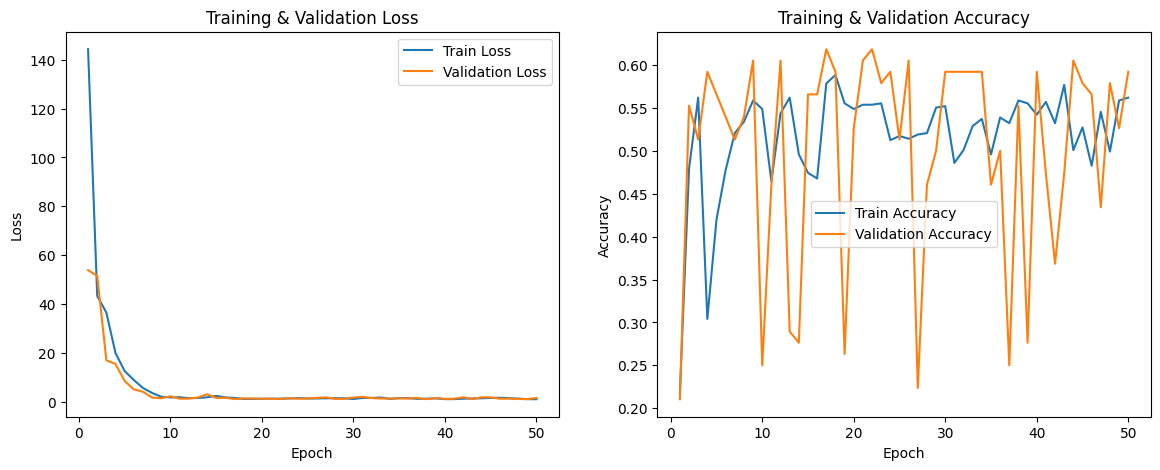

In [104]:
from torch.utils.data import TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_losses, val_losses, train_accuracies, val_accuracies = train_model(train_dataset, val_dataset, verbose=True)

epochs = range(1, 50 + 1)

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.show()


Hint: look at earlier homeworks / resuse code from those to help you here

# Part 4: Run Hyperparameter Experiments

In [105]:
# TODO - perform hyperparameter grid searches and plot accuracies
grid_results = []
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

for layers in [1, 2, 3]:
  for hidden in [32, 64, 128]:
      for lr in [1e-3, 5e-4]:
          for bs in [32, 64]:
              descriptor = f"hidden={hidden}, lr={lr}, batch={bs}, layers={layers}"
              print(f"Running {descriptor}")

              train_l, val_l, train_a, val_a = train_model(
                  train_dataset,
                  val_dataset,
                  num_layers=layers,
                  hidden_size=hidden,
                  learning_rate=lr,
                  batch_size=bs,
                  num_epochs=50
              )

              grid_results.append({
                  "hidden": hidden,
                  "lr": lr,
                  "batch": bs,
                  "layers": layers,
                  "train_acc": train_a[-1],
                  "val_acc": val_a[-1],
                  "train_curve": train_a,
                  "val_curve": val_a,
                  "train_loss": train_l,
                  "val_loss": val_l,
                  "descriptor": descriptor
              })



Running hidden=32, lr=0.001, batch=32, layers=1
Running hidden=32, lr=0.001, batch=64, layers=1
Running hidden=32, lr=0.0005, batch=32, layers=1
Running hidden=32, lr=0.0005, batch=64, layers=1
Running hidden=64, lr=0.001, batch=32, layers=1
Running hidden=64, lr=0.001, batch=64, layers=1
Running hidden=64, lr=0.0005, batch=32, layers=1
Running hidden=64, lr=0.0005, batch=64, layers=1
Running hidden=128, lr=0.001, batch=32, layers=1
Running hidden=128, lr=0.001, batch=64, layers=1
Running hidden=128, lr=0.0005, batch=32, layers=1
Running hidden=128, lr=0.0005, batch=64, layers=1
Running hidden=32, lr=0.001, batch=32, layers=2
Running hidden=32, lr=0.001, batch=64, layers=2
Running hidden=32, lr=0.0005, batch=32, layers=2
Running hidden=32, lr=0.0005, batch=64, layers=2
Running hidden=64, lr=0.001, batch=32, layers=2
Running hidden=64, lr=0.001, batch=64, layers=2
Running hidden=64, lr=0.0005, batch=32, layers=2
Running hidden=64, lr=0.0005, batch=64, layers=2
Running hidden=128, lr=0.0

In [106]:
def search_best_model(results):
    """Searches for and prints the best model hyperparams to the console"""
    best_acc = 0
    best_acc_descriptor = ''
    for result in results:
      avg_val_acc = sum(result['val_curve'])/len(result['val_curve'])
      avg_train_acc = sum(result['train_curve'])/len(result['train_curve'])
      val_acc = result['val_acc']
      train_acc = result['train_acc']
      # Combigning the average train/test loss averages and ending accuracy
      avg_acc = (avg_val_acc + avg_train_acc + val_acc + train_acc) / 4
      if avg_acc > best_acc:
        best_acc = avg_acc
        best_acc_descriptor = result['descriptor']
        print(f'New highest acc of {avg_acc} got')

    print('Final best model had the following hyperparams', best_acc_descriptor)

search_best_model(grid_results)

New highest acc of 0.5156098303610266 got
New highest acc of 0.5641637668551543 got
New highest acc of 0.5660327316224445 got
New highest acc of 0.5755921052631578 got
Final best model had the following hyperparams hidden=32, lr=0.0005, batch=32, layers=3


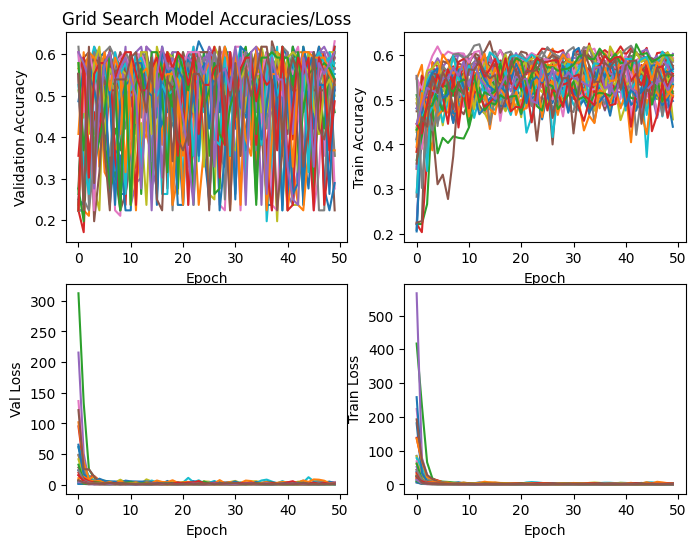

In [107]:
def quad_plot(results):
    fig, axs = plt.subplots(2, 2, figsize=(8, 6))

    for result in results:
        label = f"h={result['hidden']} lr={result['lr']} bs={result['batch']}"
        axs[0, 0].plot(result["val_curve"], label=label)
    axs[0, 0].set_xlabel("Epoch")
    axs[0, 0].set_ylabel("Validation Accuracy")
    axs[0, 0].set_title("Grid Search Model Accuracies/Loss")

    for result in results:
        label = f"h={result['hidden']} lr={result['lr']} bs={result['batch']}"
        axs[0, 1].plot(result["train_curve"], label=label)
    axs[0, 1].set_xlabel("Epoch")
    axs[0, 1].set_ylabel("Train Accuracy")

    for result in results:
        label = f"h={result['hidden']} lr={result['lr']} bs={result['batch']}"
        axs[1, 0].plot(result["val_loss"], label=label)
    axs[1, 0].set_xlabel("Epoch")
    axs[1, 0].set_ylabel("Val Loss")

    for result in results:
        label = f"h={result['hidden']} lr={result['lr']} bs={result['batch']}"
        axs[1, 1].plot(result["train_loss"], label=label)
    axs[1, 1].set_xlabel("Epoch")
    axs[1, 1].set_ylabel("Train Loss")

    plt.show()

quad_plot(grid_results)

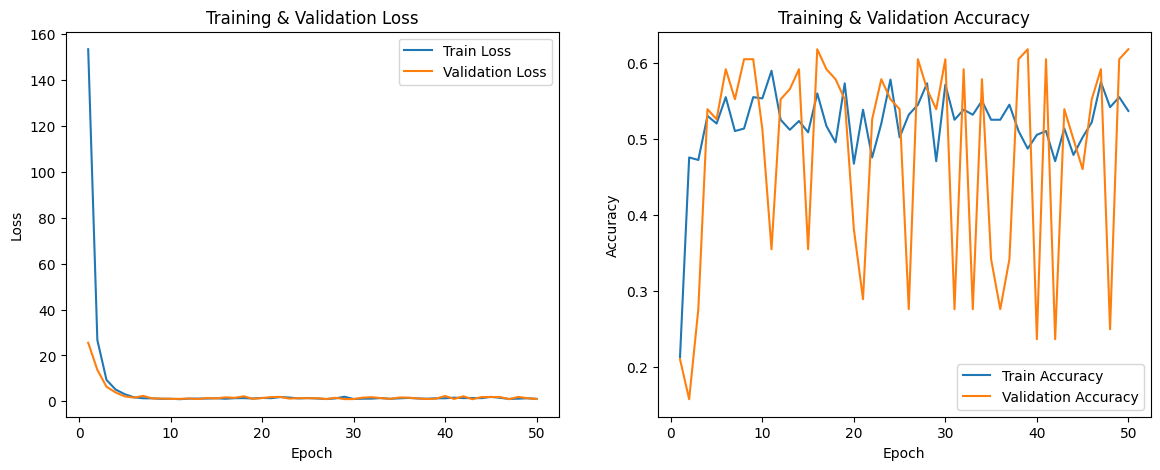

In [56]:
epochs = range(1, 50 + 1)

def get_result(results, descriptor):
  for result in grid_results:
    if result['descriptor'] != descriptor:
      continue
    else:
      return result

result = get_result(grid_results, hidden=32, lr=0.001, batch=64, layers=3)
best_model_train_accuracies = result['train_curve']
best_model_val_accuracies = result['val_curve']
best_model_train_loss = result['train_loss']
best_model_val_loss = result['val_loss']

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, best_model_train_loss, label='Train Loss')
plt.plot(epochs, best_model_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, best_model_train_accuracies, label='Train Accuracy')
plt.plot(epochs, best_model_val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.show()


## Basic Analysis
From we can see, this model kind of sucks. It seems to be overfitting the data massively since we can see drastic swings of validation accuracry every few epochs. I did a rather extensive grid search over a variety of hyperparams:
- Batch size
- Learning Rate
- Hidden Layer Size
- Layer Count

Something I would like to experiment with is adding regularization.

Another discussion point is my feature vector. Currently my features are:
`features = ['home_elo', 'away_elo', 'elo_diff', 'venue_home', 'venue_away', 'venue_neutral']
`
So really the only thing I am tracking is elo difference and home advantage. I am going to add another feature 'momentum'. This is going to be the win rate of the last 5 games played

## Generating new feature vector

In [108]:
def prepare_features(df_original):
    """Prepares the new feature vector from the og dataframe"""
    df = matches_with_elo.copy()
    df = df.sort_values('Date')

    # ================== Last 5 Games winr ate ==================
    home_team_rows = pd.DataFrame({
        "team": df["home_team"],
        "Date": df["Date"],
        "is_home": 1,
        "result": df["result"].map({
            2: 1,
            1: 0.5,
            0: 0
        })
    })

    away_team_rows = pd.DataFrame({
        "team": df["away_team"],
        "Date": df["Date"],
        "is_home": 0,
        "result": df["result"].map({
            0: 1,
            1: 0.5,
            2: 0
        })
    })

    team_results = pd.concat([home_team_rows, away_team_rows], ignore_index=True)
    team_results = team_results.sort_values("Date")

    team_results["form_5"] = (
        team_results.groupby("team")["result"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    team_results["form_5_shifted"] = (
        team_results.groupby("team")["form_5"].shift(1)
    )

    df = df.merge(
        team_results[["team", "Date", "form_5_shifted"]],
        left_on=["home_team", "Date"],
        right_on=["team", "Date"],
        how="left"
    ).rename(columns={"form_5_shifted": "home_form_5"}).drop(columns=["team"])

    df = df.merge(
        team_results[["team", "Date", "form_5_shifted"]],
        left_on=["away_team", "Date"],
        right_on=["team", "Date"],
        how="left"
    ).rename(columns={"form_5_shifted": "away_form_5"}).drop(columns=["team"])

    df["home_form_5"] = df["home_form_5"].fillna(0)
    df["away_form_5"] = df["away_form_5"].fillna(0)

    # ================== Rest Days ==================
    home_dates = df[['home_team', 'Date']].rename(columns={'home_team': 'team'})
    away_dates = df[['away_team', 'Date']].rename(columns={'away_team': 'team'})
    all_team_dates = pd.concat([home_dates, away_dates], ignore_index=True)
    all_team_dates = all_team_dates.sort_values(['team', 'Date'])

    all_team_dates['last_match_date'] = all_team_dates.groupby('team')['Date'].shift(1)
    all_team_dates['rest_days'] = (all_team_dates['Date'] - all_team_dates['last_match_date']).dt.days

    df = df.merge(
        all_team_dates[['team', 'Date', 'rest_days']],
        left_on=['home_team', 'Date'],
        right_on=['team', 'Date'],
        how='left'
    ).rename(columns={'rest_days': 'home_rest_days'}).drop(columns=['team'])

    df = df.merge(
        all_team_dates[['team', 'Date', 'rest_days']],
        left_on=['away_team', 'Date'],
        right_on=['team', 'Date'],
        how='left'
    ).rename(columns={'rest_days': 'away_rest_days'}).drop(columns=['team'])

    # Fill NaNs (first game for team)
    df['home_rest_days'] = df['home_rest_days'].fillna(7)
    df['away_rest_days'] = df['away_rest_days'].fillna(7)

    # ================== Prior features ==================
    df['elo_diff'] = df['home_elo'] - df['away_elo']
    df['venue_home'] = (df['home_team'] == df['Host']).astype(int)
    df['venue_away'] = (df['away_team'] == df['Host']).astype(int)
    df['venue_neutral'] = 1 - (df['venue_home'] | df['venue_away'])

    print(df.columns)
    return df

## Remaking test/train


In [109]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch

# Copying dataset and droping NaNs
df = prepare_features(matches_with_elo)
df = df.dropna(subset=['home_elo', 'away_elo'])

# Select features and target
features = [
    'home_elo', 'away_elo', 'elo_diff',
    'venue_home', 'venue_away', 'venue_neutral',
    'home_form_5', 'away_form_5',
    'home_rest_days', 'away_rest_days'
]
X = df[features]
y = df['result']

# train/val/test split with stratification for balanced classes
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Convert to PyTorch tensors with correct dtype
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Check shapes
print(f"Train set: {X_train_tensor.shape}, {y_train_tensor.shape}")
print(f"Validation set: {X_val_tensor.shape}, {y_val_tensor.shape}")
print(f"Test set: {X_test_tensor.shape}, {y_test_tensor.shape}")

df.head(10)

Index(['home_team', 'away_team', 'home_score', 'home_xg', 'home_penalty',
       'away_score', 'away_xg', 'away_penalty', 'home_manager', 'home_captain',
       'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials',
       'Round', 'Date', 'Score', 'Referee', 'Notes', 'Host', 'Year',
       'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long',
       'home_own_goal', 'away_own_goal', 'home_penalty_goal',
       'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long',
       'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long',
       'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long',
       'home_red_card', 'away_red_card', 'home_yellow_red_card',
       'away_yellow_red_card', 'home_yellow_card_long',
       'away_yellow_card_long', 'home_substitute_in_long',
       'away_substitute_in_long', 'result', 'home_elo', 'away_elo',
       'home_form_5', 'away_form_5', 'home_rest_days', 'away_rest_days',
       'elo_diff

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,away_manager,away_captain,Attendance,Venue,Officials,Round,Date,Score,Referee,Notes,Host,Year,home_goal,away_goal,home_goal_long,away_goal_long,home_own_goal,away_own_goal,home_penalty_goal,away_penalty_goal,home_penalty_miss_long,away_penalty_miss_long,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long,result,home_elo,away_elo,home_form_5,away_form_5,home_rest_days,away_rest_days,elo_diff,venue_home,venue_away,venue_neutral
0,France,Mexico,4,NaN,NaN,1,NaN,NaN,Raoul Caudron,Alexandre Villaplane,Juan Luque,Rafael Garza Gutiérrez,4444,"Pocitos, Montevideo",Domingo Lombardi (Referee) · Henry Cristophe (...,Group stage,1930-07-13,4–1,Domingo Lombardi,NaN,Uruguay,1930,Lucien Laurent · 19|Marcel Langiller · 40|Andr...,Juan Carreño · 70,"['19&rsquor;|1:0|Lucien Laurent', '40&rsquor;|...",['70&rsquor;|3:1|Juan Carreño'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1604.0,1549.0,0.0,0.0,7.0,7.0,55.0,0,0,1
2,Romania,Peru,3,NaN,NaN,1,NaN,NaN,Octav Luchide,Emerich Vogl,Francisco Bru,Plácido Galindo,2549,"Pocitos, Montevideo",Alberto Warnken (Referee) · Jean Langenus (AR1...,Group stage,1930-07-14,3–1,Alberto Warnken,NaN,Uruguay,1930,Adalbert Deșu · 1|Constantin Stanciu · 79|Nico...,Luis de Souza Ferreira · 75,"['1&rsquor;|1:0|Adalbert Deșu', '79&rsquor;|2:...",['75&rsquor;|1:1|Luis de Souza Ferreira'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Plácido Galindo · 70,NaN,NaN,NaN,NaN,NaN,NaN,2,1603.0,1498.0,0.0,0.0,7.0,7.0,105.0,0,0,1
3,Argentina,France,1,NaN,NaN,0,NaN,NaN,Francisco Olazar,Manuel Ferreira,Raoul Caudron,Alexandre Villaplane,23409,"Parque Central, Montevideo",Gilberto Rego (Referee) · Ulises Saucedo (AR1)...,Group stage,1930-07-15,1–0,Gilberto Rego,NaN,Uruguay,1930,Luis Monti · 81,NaN,['81&rsquor;|1:0|Luis Monti'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2075.0,1600.0,0.0,1.0,7.0,2.0,475.0,0,0,1
4,Chile,Mexico,3,NaN,NaN,0,NaN,NaN,Gyorgy Orth,Carlos Schneeberger,Juan Luque,Rafael Garza Gutiérrez,9249,"Parque Central, Montevideo",Henry Cristophe (Referee) · Martin Aphesteguy ...,Group stage,1930-07-16,3–0,Henry Cristophe,NaN,Uruguay,1930,Carlos Vidal · 3|Carlos Vidal · 65,NaN,"['3&rsquor;|1:0|Carlos Vidal', '65&rsquor;|3:0...",NaN,Manuel Rosas (OG) · 51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1624.0,1501.0,0.0,0.0,7.0,3.0,123.0,0,0,1
6,Uruguay,Peru,1,NaN,NaN,0,NaN,NaN,Alberto Suppici,José Nasazzi,Francisco Bru,Antonio Maquilón,57735,"Estadio Centenario, Montevideo",Jean Langenus (Referee) · Thomas Balway (AR1) ...,Group stage,1930-07-18,1–0,Jean Langenus,NaN,Uruguay,1930,Héctor Castro · 60,NaN,['60&rsquor;|1:0|Héctor Castro'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1969.0,1496.0,0.0,0.0,7.0,4.0,473.0,1,0,0
7,Argentina,Mexico,6,NaN,NaN,3,NaN,NaN,Francisco Olazar,Ángel Bossio,Juan Luque,Rafael Garza Gutiérrez,42100,"Estadio Centenario, Montevideo",Ulises Saucedo (Referee) · Gualberto Alonso (A...,Group stage,1930-07-19,6–3,Ulises Saucedo,NaN,Uruguay,1930,Guillermo Stábile · 8|Adolfo Zumelzú · 12|Guil...,Manuel Rosas · 65|Roberto Gayón · 75,"['8&rsquor;|1:0|Guillermo Stábile', '12&rsquor...","['65&rsquor;|5:2|Manuel Rosas', '75&rsquor;|5:...",NaN,NaN,NaN,Manuel Rosas (P) · 42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2079.0,1497.0,1.0,0.0,4.0,3.0,582.0,0,0,1
8,Chile,France,1,NaN,NaN,0,NaN,NaN,Gyorgy Orth,Carlos Schneeberger,Raoul Caudron,Alexandre Villaplane,2000,"Estadio Centenario, Montevideo",Anibal Tejada (Referee) · Domingo Lombardi (AR...,Group stage,1930-07-19,1–0,Anibal Tejada,NaN,Uruguay,1930,Guillermo Subiabre · 65,NaN,['65&rsquor;

## New Model With configurable regularization

In [110]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import torch.nn as nn
import torch
def train_model(
    train_dataset,
    val_dataset,
    hidden_size=64,
    num_layers=1,
    learning_rate=0.001,
    batch_size=64,
    num_epochs=50,
    verbose=False,
    weight_decay=0
):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # build loaders with chosen batch size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = 'a' # Listen, this looks stupid, but its the only way to clean this variable in collab, dont judge me
    model = MatchPredictorNN(input_dim=10,
                             hidden_size=hidden_size,
                             num_layers=num_layers).to(device)

    criterion = 'b'
    criterion = nn.CrossEntropyLoss()
    optimizer = 'c'
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay) # Added weight decay, 0 is no reg, 1e-4 is L2

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        # -------- train --------
        model.train()
        epoch_loss = 0
        preds, labels = [], []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds.extend(outputs.argmax(1).cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

        train_loss = epoch_loss / len(train_loader)
        train_acc  = accuracy_score(labels, preds)

        # -------- val --------
        model.eval()
        epoch_loss = 0
        preds, labels = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                epoch_loss += loss.item()
                preds.extend(outputs.argmax(1).cpu().numpy())
                labels.extend(y_batch.cpu().numpy())

        val_loss = epoch_loss / len(val_loader)
        val_acc  = accuracy_score(labels, preds)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Acc {train_acc:.3f} | Val Acc {val_acc:.3f}")

    return train_losses, val_losses, train_accs, val_accs


## New Training Loop

In [111]:
# TODO - perform hyperparameter grid searches and plot accuracies
grid_results = []
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

for regularization in [0, 1e-4]:
    for layers in [1, 2, 3]:
        for hidden in [32, 64, 128]:
            for lr in [1e-3, 5e-4]:
                for bs in [32, 64]:
                    descriptor = f"hidden={hidden}, lr={lr}, batch={bs}, layers={layers}, regularization={regularization}"
                    print(f"Running {descriptor}")

                    train_l, val_l, train_a, val_a = train_model(
                        train_dataset,
                        val_dataset,
                        num_layers=layers,
                        hidden_size=hidden,
                        learning_rate=lr,
                        batch_size=bs,
                        num_epochs=50
                    )

                    grid_results.append({
                        "hidden": hidden,
                        "lr": lr,
                        "batch": bs,
                        "layers": layers,
                        "regularization": regularization,
                        "train_acc": train_a[-1],
                        "val_acc": val_a[-1],
                        "train_curve": train_a,
                        "val_curve": val_a,
                        "train_loss": train_l,
                        "val_loss": val_l,
                        "descriptor": descriptor
                    })

Running hidden=32, lr=0.001, batch=32, layers=1, regularization=0
Running hidden=32, lr=0.001, batch=64, layers=1, regularization=0
Running hidden=32, lr=0.0005, batch=32, layers=1, regularization=0
Running hidden=32, lr=0.0005, batch=64, layers=1, regularization=0
Running hidden=64, lr=0.001, batch=32, layers=1, regularization=0
Running hidden=64, lr=0.001, batch=64, layers=1, regularization=0
Running hidden=64, lr=0.0005, batch=32, layers=1, regularization=0
Running hidden=64, lr=0.0005, batch=64, layers=1, regularization=0
Running hidden=128, lr=0.001, batch=32, layers=1, regularization=0
Running hidden=128, lr=0.001, batch=64, layers=1, regularization=0
Running hidden=128, lr=0.0005, batch=32, layers=1, regularization=0
Running hidden=128, lr=0.0005, batch=64, layers=1, regularization=0
Running hidden=32, lr=0.001, batch=32, layers=2, regularization=0
Running hidden=32, lr=0.001, batch=64, layers=2, regularization=0
Running hidden=32, lr=0.0005, batch=32, layers=2, regularization=0

New highest acc of 0.548838165550286 got
New highest acc of 0.6252415293599961 got
New highest acc of 0.6352069623038186 got
New highest acc of 0.657212976091527 got
New highest acc of 0.6659732068645187 got
New highest acc of 0.6797116315454945 got
New highest acc of 0.6801063413680145 got
New highest acc of 0.6807750452256393 got
Final best model had the following hyperparams hidden=64, lr=0.0005, batch=32, layers=3, regularization=0.0001


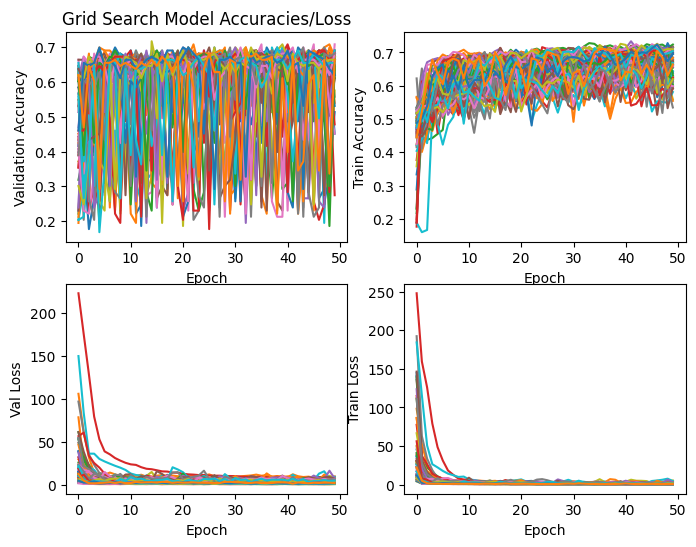

In [113]:
search_best_model(grid_results)
quad_plot(grid_results)

## Best Model Plotting

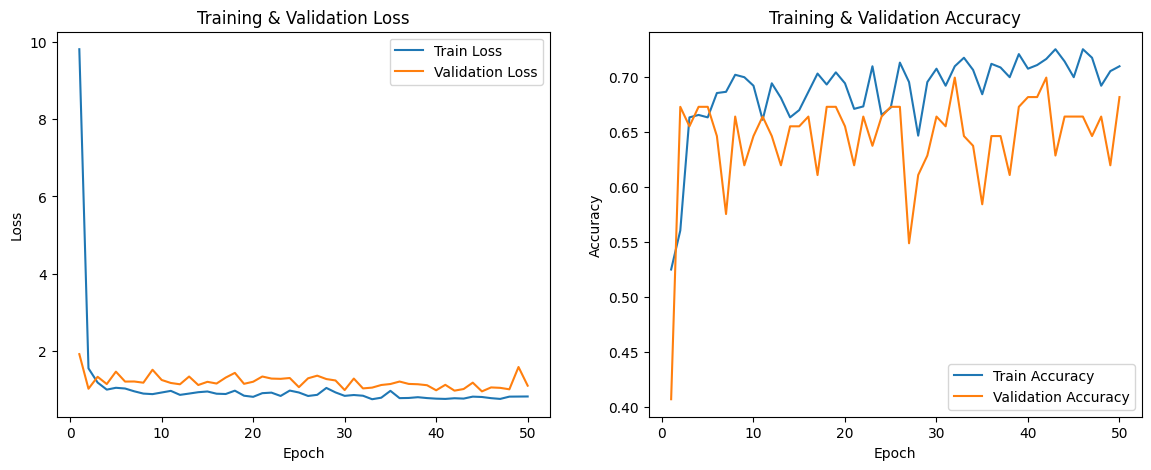

In [115]:
epochs = range(1, 50 + 1)

def get_result(results, descriptor):
  for result in grid_results:
    if result['descriptor'] != descriptor:
      continue
    else:
      return result

result = get_result(grid_results, "hidden=64, lr=0.0005, batch=32, layers=3, regularization=0.0001")
best_model_train_accuracies = result['train_curve']
best_model_val_accuracies = result['val_curve']
best_model_train_loss = result['train_loss']
best_model_val_loss = result['val_loss']

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, best_model_train_loss, label='Train Loss')
plt.plot(epochs, best_model_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, best_model_train_accuracies, label='Train Accuracy')
plt.plot(epochs, best_model_val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.show()

## Best Model but without regularization

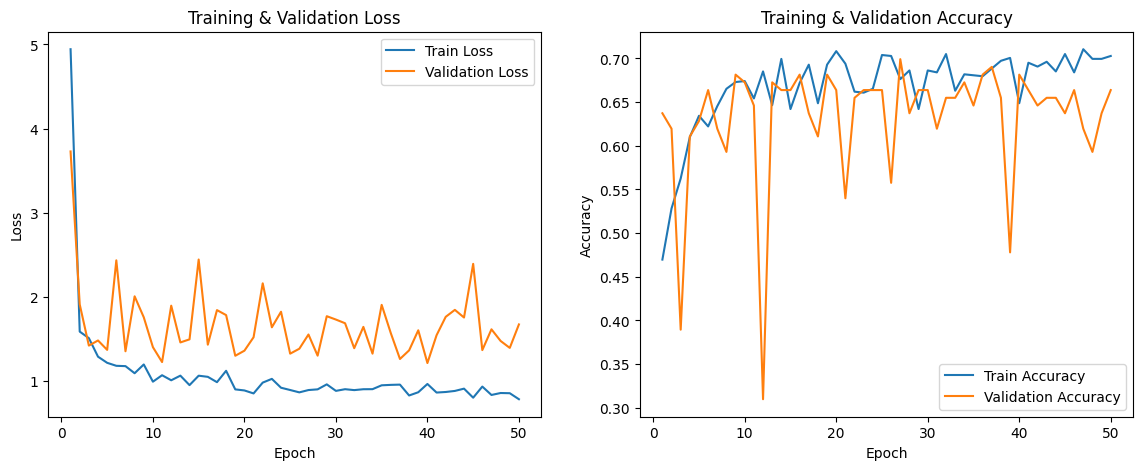

In [116]:
epochs = range(1, 50 + 1)

result = get_result(grid_results, "hidden=64, lr=0.0005, batch=32, layers=3, regularization=0")
best_model_train_accuracies = result['train_curve']
best_model_val_accuracies = result['val_curve']
best_model_train_loss = result['train_loss']
best_model_val_loss = result['val_loss']

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, best_model_train_loss, label='Train Loss')
plt.plot(epochs, best_model_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, best_model_train_accuracies, label='Train Accuracy')
plt.plot(epochs, best_model_val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.show()

## Final Analysis
So ultimately this further experimentation was an overwhelming success. The additional features of, last 5 game winrate and team fatigue, significantly increased the performance of our model from 56% to 68%. Our model still seems to be overfitting by a margin of 10%, but it is not that bad. The regularization did help reduce some of the drastic accuracy swings but it had a much better effect on loss. Overall I think it is safe to say the additional features made more of an impact.

**So our final accuracy is 69%**

I believe the reason why recent winrate and fatigue were so instrumental is because our prior model ran exlusively on elo and home advantage. Home advantage is rare in World Cups and elo does not really resemble the uniqueness of the teams. Winrate does actually capture if a team has recently added good players, or is generally on a hot streak.

This performance increase was similar to that of the Soccer Result Prediction Using Deep Learning and Neural Networks paper. Ironically my model is very similar to theirs, but they have more granular data.


### Further exploration
If I could add more data then Ideally I would word2vec the player roster of every team/match.

Also there are a few more model alterations. For example, random neuron dropping might improve overfitting